In [22]:
# ==========================================
# CELL 1 — LOAD LIQUID OPTIONS + REBUILD CORRECTED IVs
# ==========================================
# This repeats the fixed forward + IV logic from notebook 3, so notebook 4
# can run standalone. If you already saved the notebook-3 output to a CSV,
# you can skip straight to loading that file instead - see the commented
# alternative at the bottom of this cell.

import os
import numpy as np
import pandas as pd
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

folder = r"C:\Users\ASUS\Desktop\volPredict"

print("=== LOADING LIQUID OPTIONS DATA ===")
df = pd.read_csv(os.path.join(folder, "options_liquid.csv"))
df["Date"] = pd.to_datetime(df["Date"])
df["Expiry"] = pd.to_datetime(df["Expiry"])
print(f"✓ Loaded {len(df):,} liquid option records.")

print("=== EXTRACTING FORWARD PRICE VIA PUT-CALL PARITY ===")

def extract_forward_for_group(group):
    calls = group[group["Type"] == "CE"][["Strike Price", "Close"]].rename(columns={"Close": "Call_Close"})
    puts = group[group["Type"] == "PE"][["Strike Price", "Close"]].rename(columns={"Close": "Put_Close"})
    merged = pd.merge(calls, puts, on="Strike Price", how="inner")
    if len(merged) < 3:
        return pd.Series({"Forward": np.nan, "DiscountFactor": np.nan})
    K = merged["Strike Price"].values
    C_minus_P = (merged["Call_Close"] - merged["Put_Close"]).values
    slope, intercept = np.polyfit(K, C_minus_P, 1)
    discount_factor = -slope
    if discount_factor <= 0:
        return pd.Series({"Forward": np.nan, "DiscountFactor": np.nan})
    return pd.Series({"Forward": intercept / discount_factor, "DiscountFactor": discount_factor})

forward_table = df.groupby(["Date", "Expiry"]).apply(extract_forward_for_group).reset_index()
df = df.merge(forward_table, on=["Date", "Expiry"], how="left")
df = df.dropna(subset=["Forward", "DiscountFactor"]).copy()
print(f"✓ Forward extracted. {len(df):,} rows remain after dropping ungroupable rows.")

def vectorized_implied_volatility(S, K, T, market_price, flag, r=0.0, q=0.0, tol=1e-4, max_iter=100):
    sigma = np.full_like(S, 0.3, dtype=float)
    exp_qT = np.exp(-q * T)
    exp_rT = np.exp(-r * T)
    is_call = (flag == "CE")
    for i in range(max_iter):
        sigma_sqrt_T = np.where(sigma * np.sqrt(T) == 0, 1e-9, sigma * np.sqrt(T))
        d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / sigma_sqrt_T
        d2 = d1 - sigma_sqrt_T
        price_c = S * exp_qT * norm.cdf(d1) - K * exp_rT * norm.cdf(d2)
        price_p = K * exp_rT * norm.cdf(-d2) - S * exp_qT * norm.cdf(-d1)
        model_price = np.where(is_call, price_c, price_p)
        vega = S * exp_qT * norm.pdf(d1) * np.sqrt(T)
        vega = np.where(vega < 1e-6, 1e-6, vega)
        diff = model_price - market_price
        sigma = np.clip(sigma - diff / vega, 1e-4, 5.0)
        if np.max(np.abs(diff)) < tol:
            break
    return sigma

print("=== SOLVING IMPLIED VOLATILITY ===")
S = df["Forward"].values
K = df["Strike Price"].values
T = df["DTE"].values / 365.0
market_price = df["Close"].values
flag = df["Type"].values
df["IV"] = vectorized_implied_volatility(S, K, T, market_price, flag, r=0.0, q=0.0)
df["LogMoneyness"] = np.log(df["Strike Price"] / df["Forward"])
print(f"✓ IV solved for {len(df):,} rows.")

# --- Alternative: if you saved notebook 3's df to a csv, just do this instead ---
# df = pd.read_csv(os.path.join(folder, "options_iv_corrected.csv"), parse_dates=["Date", "Expiry"])

=== LOADING LIQUID OPTIONS DATA ===
✓ Loaded 386,942 liquid option records.
=== EXTRACTING FORWARD PRICE VIA PUT-CALL PARITY ===
✓ Forward extracted. 378,932 rows remain after dropping ungroupable rows.
=== SOLVING IMPLIED VOLATILITY ===
✓ IV solved for 378,932 rows.


In [23]:
# ==========================================
# CELL 2 — CLEAN UP JUNK BEFORE FITTING SMILES
# ==========================================
# A handful of rows have unreliable IVs - usually deep out-of-the-money
# options with a stale or near-zero closing price, where the solver just
# hits its floor (0.0001) instead of finding a real answer. Fitting a smile
# curve through these points would distort the whole shape, so we drop them.

print("=== FILTERING UNRELIABLE IV POINTS ===")
before = len(df)

clean = df[
    (df["IV"] > 0.02) & (df["IV"] < 2.0) &                    # drop solver floor/ceiling hits
    (df["LogMoneyness"].abs() < 0.5) &                        # drop extreme deep ITM/OTM strikes
    (df["No. of contracts"] >= 10)                             # drop near-zero-volume quotes
].copy()

print(f"✓ Kept {len(clean):,} / {before:,} rows ({100*len(clean)/before:.1f}%) for smile fitting.")

=== FILTERING UNRELIABLE IV POINTS ===
✓ Kept 362,025 / 378,932 rows (95.5%) for smile fitting.


In [24]:
# ==========================================
# CELL 3 — FIT A SMILE CURVE PER (DATE, EXPIRY)
# ==========================================
# A global polynomial (quadratic, or even quartic) forces one algebraic shape
# across the WHOLE strike range. Real NIFTY smiles typically look closer to
# roughly straight wings on both sides bending into a rounded dip near the
# money - which a global polynomial can only approximate by trading off
# accuracy in one region for another. A quartic reduced error somewhat over
# a quadratic, but a REGULARIZED SMOOTHING SPLINE tracks this shape better
# still, without needing us to hand-pick a polynomial degree or a kink point.
#
# IMPORTANT CALIBRATION NOTE: splines are flexible enough to overfit
# individual noisy quotes if under-smoothed (verified directly - a lightly
# smoothed spline visibly oscillated between points, chasing noise rather
# than the market's actual smile shape). The smoothing parameter below was
# chosen specifically to avoid this - deliberately weighted heavy, following
# scipy's guidance that s should scale with n_points * variance(IV).
#
# We still summarize each day's smile with a compact set of numbers per
# expiry (level, skew, curvature, evaluated from the spline itself), so
# downstream notebooks needing this shape as model features are unaffected.

from scipy.interpolate import UnivariateSpline

print("=== FITTING SMILE CURVES PER (DATE, EXPIRY) ===")

MIN_POINTS_FOR_SPLINE = 8       # need enough strikes for a stable cubic spline
SPLINE_SMOOTHING_FACTOR = 3.0   # multiplier on n*variance(IV) - higher = smoother, less noise-chasing

def fit_smile(group):
    n = len(group)
    if n < MIN_POINTS_FOR_SPLINE:
        return pd.Series({
            "level": np.nan, "skew": np.nan, "curvature": np.nan,
            "n_points": n, "fit_rmse": np.nan, "fit_method": np.nan,
        })

    k = group["LogMoneyness"].values
    iv = group["IV"].values

    # UnivariateSpline requires strictly increasing x - average duplicate
    # log-moneyness points (can happen if two contracts share a strike/DTE).
    order = np.argsort(k)
    k_sorted, iv_sorted = k[order], iv[order]
    k_unique, inverse = np.unique(k_sorted, return_inverse=True)
    if len(k_unique) < len(k_sorted):
        iv_unique = np.array([iv_sorted[inverse == i].mean() for i in range(len(k_unique))])
    else:
        iv_unique = iv_sorted

    if len(k_unique) < MIN_POINTS_FOR_SPLINE:
        return pd.Series({
            "level": np.nan, "skew": np.nan, "curvature": np.nan,
            "n_points": n, "fit_rmse": np.nan, "fit_method": np.nan,
        })

    s_val = len(k_unique) * np.var(iv_unique) * SPLINE_SMOOTHING_FACTOR
    try:
        spline = UnivariateSpline(k_unique, iv_unique, k=3, s=s_val)
        fitted = spline(k_unique)
        rmse = np.sqrt(np.mean((fitted - iv_unique) ** 2))

        # Level / skew / curvature: the spline's value and first two
        # derivatives evaluated AT k=0 (or the nearest point to it if 0 is
        # outside the fitted range that day) - same interpretation as before,
        # just read off a smoother underlying curve instead of a polynomial.
        k_eval = 0.0 if (k_unique.min() <= 0 <= k_unique.max()) else k_unique[np.argmin(np.abs(k_unique))]
        level = float(spline(k_eval))
        skew = float(spline.derivative(1)(k_eval))
        curvature = float(spline.derivative(2)(k_eval))

        return pd.Series({
            "level": level, "skew": skew, "curvature": curvature,
            "n_points": n, "fit_rmse": rmse, "fit_method": "spline",
        })
    except Exception:
        return pd.Series({
            "level": np.nan, "skew": np.nan, "curvature": np.nan,
            "n_points": n, "fit_rmse": np.nan, "fit_method": np.nan,
        })

smile_table = clean.groupby(["Date", "Expiry", "DTE"]).apply(fit_smile).reset_index()
smile_table = smile_table.dropna(subset=["level"])

print(f"✓ Fitted {len(smile_table):,} smile curves using regularized smoothing splines.")
print()
print("--- Fit quality (RMSE of fitted curve vs actual IV points) ---")
print(smile_table["fit_rmse"].describe())
print()
print(smile_table.head(10))


=== FITTING SMILE CURVES PER (DATE, EXPIRY) ===
✓ Fitted 4,245 smile curves using regularized smoothing splines.

--- Fit quality (RMSE of fitted curve vs actual IV points) ---
count    4245.000000
mean        0.007366
std         0.007819
min         0.000625
25%         0.003320
50%         0.004947
75%         0.007758
max         0.126774
Name: fit_rmse, dtype: float64

         Date     Expiry  DTE     level      skew  curvature  n_points  \
0  2021-01-01 2021-01-07    6  0.148882 -0.516959  36.456962      93.0   
1  2021-01-01 2021-01-14   13  0.161875 -0.351688  15.559373      62.0   
2  2021-01-01 2021-01-28   27  0.180207 -0.398301   3.661645      98.0   
3  2021-01-01 2021-02-25   55  0.207049 -0.250349   0.079200      41.0   
4  2021-01-01 2021-03-25   83  0.198840 -0.213245   0.082973      17.0   
6  2021-01-04 2021-01-07    3  0.178849 -0.948565  60.027732      94.0   
7  2021-01-04 2021-01-14   10  0.161889 -0.589272  23.062267      71.0   
8  2021-01-04 2021-01-21   17  

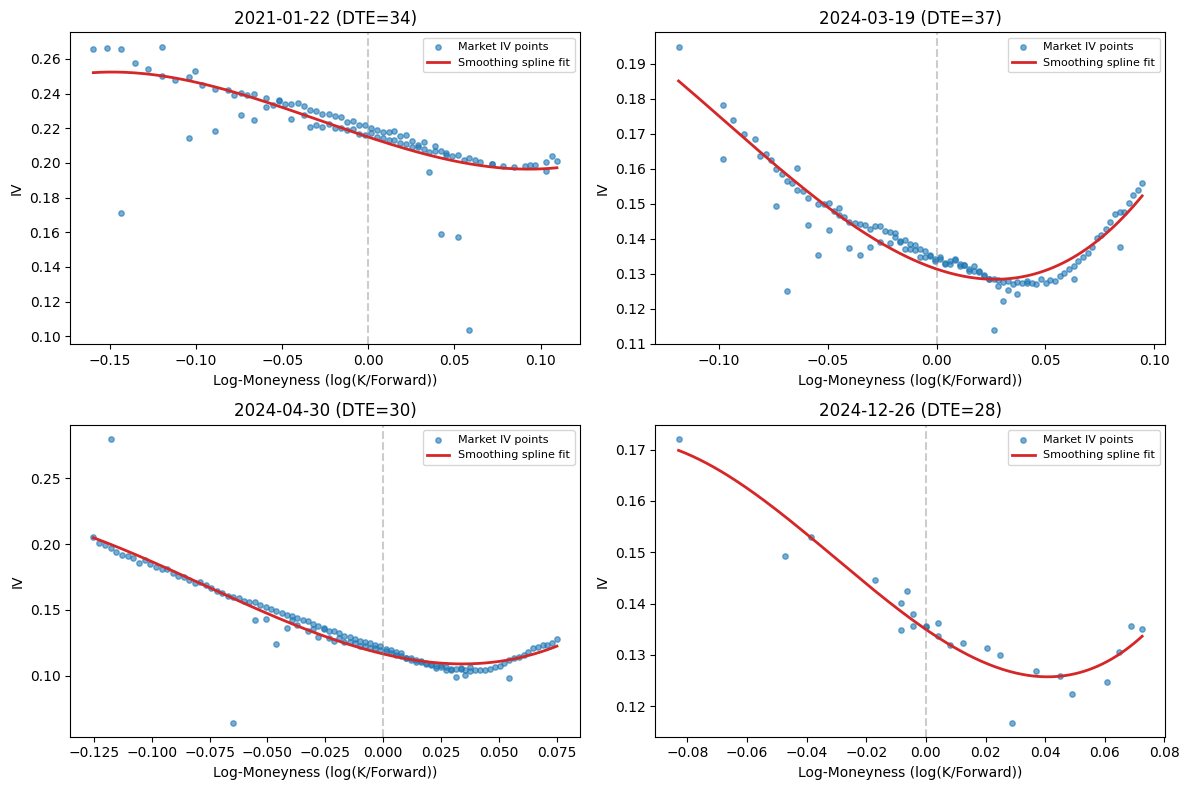

Each red curve is the fitted regularized smoothing spline for that day.


In [25]:
# ==========================================
# CELL 4 — VISUALIZE A FEW SAMPLE SMILES
# ==========================================
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

sample_dates = clean["Date"].drop_duplicates().sample(4, random_state=42).sort_values()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, sample_date in zip(axes.flat, sample_dates):
    day_data = clean[clean["Date"] == sample_date]
    nearest_expiry = day_data.loc[day_data["DTE"].sub(30).abs().idxmin(), "Expiry"]
    sub = day_data[day_data["Expiry"] == nearest_expiry].sort_values("LogMoneyness")

    k = sub["LogMoneyness"].values
    iv = sub["IV"].values
    order = np.argsort(k)
    k_sorted, iv_sorted = k[order], iv[order]
    k_unique, inverse = np.unique(k_sorted, return_inverse=True)
    if len(k_unique) < len(k_sorted):
        iv_unique = np.array([iv_sorted[inverse == i].mean() for i in range(len(k_unique))])
    else:
        iv_unique = iv_sorted

    ax.scatter(sub["LogMoneyness"], sub["IV"], s=15, alpha=0.6, label="Market IV points")

    if len(k_unique) >= MIN_POINTS_FOR_SPLINE:
        s_val = len(k_unique) * np.var(iv_unique) * SPLINE_SMOOTHING_FACTOR
        spline = UnivariateSpline(k_unique, iv_unique, k=3, s=s_val)
        k_range = np.linspace(k_unique.min(), k_unique.max(), 200)
        fitted_curve = spline(k_range)
        ax.plot(k_range, fitted_curve, color="tab:red", linewidth=2, label="Smoothing spline fit")

    ax.axvline(0, linestyle="--", color="gray", alpha=0.4)
    actual_dte = day_data[day_data["Expiry"] == nearest_expiry]["DTE"].iloc[0]
    ax.set_title(f"{sample_date.date()} (DTE={actual_dte})")
    ax.set_xlabel("Log-Moneyness (log(K/Forward))")
    ax.set_ylabel("IV")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("sample_smiles.png", dpi=100)
plt.show()
print("Each red curve is the fitted regularized smoothing spline for that day.")


In [26]:
# ==========================================
# CELL 5 — BUILD DAILY SMILE FEATURES AT FIXED TENORS (7D, 14D, 30D)
# ==========================================
# Each day usually has several expiries available (weekly + monthly), each
# with its own smile fit. To get ONE clean number per day (so this lines up
# with daily_volatility_features.csv), we pick the expiry closest to 7, 14,
# and 30 calendar days out, for every date. A 7-day tenor is added here in
# addition to the original 14D/30D - short-dated options have enough
# liquidity in this dataset (median ~130 strikes per expiry-date group for
# DTE 5-9) to support a reliable smile fit at this horizon too.

print("=== SELECTING NEAREST-TENOR SMILE PER DAY (7D, 14D, 30D) ===")

def nearest_tenor_smile(group, target_dte):
    idx = group["DTE"].sub(target_dte).abs().idxmin()
    return group.loc[idx]

def build_tenor_table(smile_table, target_dte, label):
    picked = smile_table.loc[
        smile_table.groupby("Date")["DTE"].apply(lambda s: s.sub(target_dte).abs().idxmin())
    ].copy()
    picked = picked[["Date", "DTE", "level", "skew", "curvature", "n_points", "fit_rmse"]].rename(
        columns={
            "DTE": f"DTE_{label}",
            "level": f"Smile_Level_{label}",
            "skew": f"Smile_Skew_{label}",
            "curvature": f"Smile_Curv_{label}",
            "n_points": f"N_Points_{label}",
            "fit_rmse": f"Fit_RMSE_{label}",
        }
    )
    return picked

smile_7d = build_tenor_table(smile_table, 7, "7D")
smile_14d = build_tenor_table(smile_table, 14, "14D")
smile_30d = build_tenor_table(smile_table, 30, "30D")

daily_smile_features = pd.merge(smile_7d, smile_14d, on="Date", how="inner")
daily_smile_features = pd.merge(daily_smile_features, smile_30d, on="Date", how="inner")

# Term structure of curvature/skew - how the smile SHAPE (not just level)
# changes ACROSS tenors. This is genuinely new information beyond what
# daily_volatility_features.csv already has (which only covers 14D/30D).
daily_smile_features["Skew_Term_Slope_30_14"] = daily_smile_features["Smile_Skew_30D"] - daily_smile_features["Smile_Skew_14D"]
daily_smile_features["Curv_Term_Slope_30_14"] = daily_smile_features["Smile_Curv_30D"] - daily_smile_features["Smile_Curv_14D"]
daily_smile_features["Skew_Term_Slope_14_7"] = daily_smile_features["Smile_Skew_14D"] - daily_smile_features["Smile_Skew_7D"]
daily_smile_features["Curv_Term_Slope_14_7"] = daily_smile_features["Smile_Curv_14D"] - daily_smile_features["Smile_Curv_7D"]

# Kept for backward compatibility with notebooks that expect the original
# (30D minus 14D) column names without the _30_14 suffix.
daily_smile_features["Skew_Term_Slope"] = daily_smile_features["Skew_Term_Slope_30_14"]
daily_smile_features["Curv_Term_Slope"] = daily_smile_features["Curv_Term_Slope_30_14"]

print(f"✓ Built daily smile feature table: {len(daily_smile_features):,} rows.")
print(f"  Columns: {daily_smile_features.columns.tolist()}")
print(daily_smile_features.head())


=== SELECTING NEAREST-TENOR SMILE PER DAY (7D, 14D, 30D) ===
✓ Built daily smile feature table: 656 rows.
  Columns: ['Date', 'DTE_7D', 'Smile_Level_7D', 'Smile_Skew_7D', 'Smile_Curv_7D', 'N_Points_7D', 'Fit_RMSE_7D', 'DTE_14D', 'Smile_Level_14D', 'Smile_Skew_14D', 'Smile_Curv_14D', 'N_Points_14D', 'Fit_RMSE_14D', 'DTE_30D', 'Smile_Level_30D', 'Smile_Skew_30D', 'Smile_Curv_30D', 'N_Points_30D', 'Fit_RMSE_30D', 'Skew_Term_Slope_30_14', 'Curv_Term_Slope_30_14', 'Skew_Term_Slope_14_7', 'Curv_Term_Slope_14_7', 'Skew_Term_Slope', 'Curv_Term_Slope']
        Date  DTE_7D  Smile_Level_7D  Smile_Skew_7D  Smile_Curv_7D  \
0 2021-01-01       6        0.148882      -0.516959      36.456962   
1 2021-01-04      10        0.161889      -0.589272      23.062267   
2 2021-01-07       7        0.160960      -0.698829      32.130241   
3 2021-01-11      10        0.184377      -0.844591      20.118377   
4 2021-01-12       9        0.181471      -0.939160      27.075488   

   N_Points_7D  Fit_RMSE_7D  

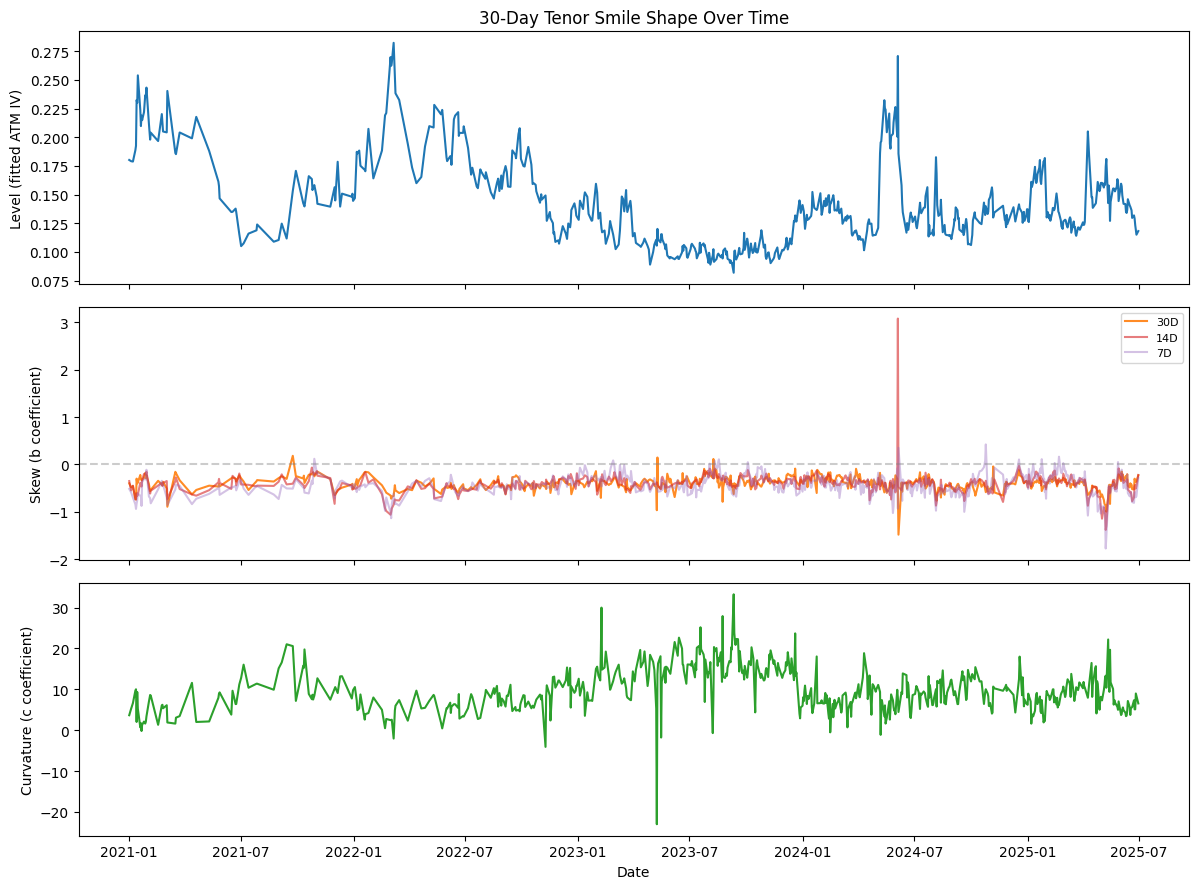

✓ Skew should mostly be negative (equity index pattern). Curvature spikes
  often line up with market stress periods.


In [27]:
# ==========================================
# CELL 6 — TIME SERIES OF SMILE SHAPE (SANITY CHECK)
# ==========================================
# If the shape features are meaningful, curvature and skew should move
# noticeably around known volatile periods, not just sit flat.

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(daily_smile_features["Date"], daily_smile_features["Smile_Level_30D"], color="tab:blue")
axes[0].set_ylabel("Level (fitted ATM IV)")
axes[0].set_title("30-Day Tenor Smile Shape Over Time")

axes[1].plot(daily_smile_features["Date"], daily_smile_features["Smile_Skew_30D"], color="tab:orange", label="30D", alpha=0.9)
axes[1].plot(daily_smile_features["Date"], daily_smile_features["Smile_Skew_14D"], color="tab:red", label="14D", alpha=0.6)
axes[1].plot(daily_smile_features["Date"], daily_smile_features["Smile_Skew_7D"], color="tab:purple", label="7D", alpha=0.4)
axes[1].axhline(0, linestyle="--", color="gray", alpha=0.4)
axes[1].set_ylabel("Skew (b coefficient)")
axes[1].legend(fontsize=8, loc="upper right")

axes[2].plot(daily_smile_features["Date"], daily_smile_features["Smile_Curv_30D"], color="tab:green")
axes[2].set_ylabel("Curvature (c coefficient)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.savefig("smile_shape_timeseries.png", dpi=100)
plt.show()
print("✓ Skew should mostly be negative (equity index pattern). Curvature spikes")
print("  often line up with market stress periods.")

In [28]:
# ==========================================
# CELL 7 — SAVE SMILE FEATURES FOR USE IN NOTEBOOK 5
# ==========================================
out_path = os.path.join(folder, "smile_features.csv")
daily_smile_features.to_csv(out_path, index=False)
print(f"✓ Saved daily smile shape features to: {out_path}")
print(f"  Columns: {daily_smile_features.columns.tolist()}")

✓ Saved daily smile shape features to: C:\Users\ASUS\Desktop\volPredict\smile_features.csv
  Columns: ['Date', 'DTE_7D', 'Smile_Level_7D', 'Smile_Skew_7D', 'Smile_Curv_7D', 'N_Points_7D', 'Fit_RMSE_7D', 'DTE_14D', 'Smile_Level_14D', 'Smile_Skew_14D', 'Smile_Curv_14D', 'N_Points_14D', 'Fit_RMSE_14D', 'DTE_30D', 'Smile_Level_30D', 'Smile_Skew_30D', 'Smile_Curv_30D', 'N_Points_30D', 'Fit_RMSE_30D', 'Skew_Term_Slope_30_14', 'Curv_Term_Slope_30_14', 'Skew_Term_Slope_14_7', 'Curv_Term_Slope_14_7', 'Skew_Term_Slope', 'Curv_Term_Slope']
